---
---

# 💧🌱 S6E04 | Irrigation Need


---
---

## Setup

### Dependencies, imports and configs

In [1]:
%%capture
!pip install itables \
    catboost \
    optuna-integration[xgboost] \
    # optuna-integration[lightgbm] \
    # optuna-integration[catboost] \
    # scikit-learn==1.3.1 # for target_encoder

In [2]:
import os
from typing import Optional
from dataclasses import dataclass, asdict, field

import time
import torch
import random
from math import e
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=False,connected=True)

# Sklearn Preprocessing
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, PolynomialFeatures, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# The Models
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor

# Metrics
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    balanced_accuracy_score)

# Hyperparameter search
import optuna

# Set plot style
sns.set_style("darkgrid")

# Silence FutureWarnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
@dataclass
class EnvConfig:
    competition: str = "playground-series-s6e4"
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    smoke_test: bool = True
    requires_keys: bool = True
    report_to_wandb: bool = False
    use_accelerator: bool = False
    mixed_precision: bool = False
    is_kaggle: bool = "KAGGLE_" in "".join(os.environ.keys())

@dataclass
class DataConfig:
    data_path: str = ""
    extra_path: str = ""
    target: str = "irrigation_need"
    metric: str = "roc_auc"
    folds: int = 5
    add_extra_data: bool = False
    add_features: bool = False
    feature_selection: bool = False
    use_te: bool = False # Target Encoding

@dataclass
class ModelConfig:
    task_type: str = "classification"
    model_type: str = "tree-based"
    adversarial_threshold: float = 0.65
    hp_search: bool = False
    optimized_params: bool = False
    search_weights: bool = True
    optuna_trials: int = 30
    params: dict = field(default_factory=lambda: {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "learning_rate": 0.05,
        "max_depth": 3,
        "tree_method": "gpu_hist" if torch.cuda.is_available() else "hist",
    })

@dataclass
# NOTE: Use default_factory for mutable default values to prevent unintended shared state.
class CFG:
    env: EnvConfig = field(default_factory=EnvConfig)
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)

    # Placeholder for the secret key
    wandb_api_key: Optional[str] = field(default=None, repr=False)

    def __post_init__(self):
        """Runs automatically after the class is initialized."""
        # 1. Handle W&B Secrets
        if self.env.requires_keys:
            if self.env.is_kaggle:
                try:
                    from kaggle_secrets import UserSecretsClient
                    os.environ["WANDB_API_KEY"] = UserSecretsClient().get_secret("WANDB_API_KEY")
                    print("✅ Secrets loaded.")
                except Exception as e:
                    print(f"ℹ️ Kaggle secrets not found: {e}")
            else:
                try:
                    from google.colab import userdata
                    # os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
                    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
                    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
                    print("✅ Secrets loaded.")
                except Exception as e:
                    print(f"ℹ️ Colab secrets not found: {e}")

        if self.env.use_accelerator:
            # 2. Handle cuML Acceleration
            if self.env.use_accelerator:
                try:
                    import cuml.accel
                    cuml.accel.install()
                    print("⚡ GPU Acceleration Enabled")
                except Exception as e:
                    print(f"ℹ️ cuML Acceleration unavailable: {e}")

    def to_dict(self):
        """Best for wandb.init(config=...)"""
        return asdict(self)

# Instantiate
config = CFG()
if not config.env.is_kaggle:
    import kagglehub
    playground_series_path = kagglehub.competition_download(config.env.competition)
    config.data.data_path = playground_series_path
    # Ensure the target is correctly set for this competition
    config.data.target = "irrigation_need"
    if config.data.add_extra_data:
        try:
            extra_data_path = kagglehub.dataset_download("PLACEHOLDER")
            config.data.extra_path = extra_data_path + "PLACEHOLDER.csv"
            print("✅ Extra data loaded.")
        except Exception as e:
            print(f"ℹ️ Extra data not found: {e}")
else:
    config.data.data_path = f'/kaggle/input/competitions/{config.env.competition}'

✅ Secrets loaded.


100%|██████████| 32.5M/32.5M [00:00<00:00, 135MB/s]

Extracting files...


In [7]:
pprint(config.to_dict())

{'data': {'add_extra_data': False,
          'add_features': False,
          'data_path': '/root/.cache/kagglehub/competitions/playground-series-s6e4',
          'extra_path': '',
          'feature_selection': False,
          'folds': 5,
          'metric': 'roc_auc',
          'target': 'irrigation_need',
          'use_te': False},
 'env': {'competition': 'playground-series-s6e4',
         'device': 'cuda',
         'is_kaggle': False,
         'mixed_precision': False,
         'report_to_wandb': False,
         'requires_keys': True,
         'seed': 42,
         'smoke_test': True,
         'use_accelerator': False},
 'model': {'adversarial_threshold': 0.65,
           'hp_search': False,
           'model_type': 'tree-based',
           'optimized_params': False,
           'optuna_trials': 30,
           'params': {'eval_metric': 'auc',
                      'learning_rate': 0.05,
                      'max_depth': 3,
                      'objective': 'binary:logistic',
    

In [8]:
if config.env.report_to_wandb:
    import wandb
    wandb.init(project=config.env.competition, config=config.to_dict())

### src

In [9]:
#@title src/utils

def seed_everything(seed: int):
    np.random.seed(config.env.seed)
    random.seed(config.env.seed)
    torch.manual_seed(config.env.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(config.env.seed)
        torch.cuda.manual_seed_all(config.env.seed)
        torch.backends.cudnn.deterministic = True
        # torch.backends.cudnn.benchmark = False

def iqr_outlier_capping(train, valid=None, test=None, columns=None):
    """
    Applies IQR-based outlier capping to specified columns of one, two, or three DataFrames.

    Parameters:
        train (pd.DataFrame): The training DataFrame used to calculate IQR thresholds.
        valid (pd.DataFrame, optional): The validation DataFrame to cap using train thresholds.
        test (pd.DataFrame, optional): The test DataFrame to cap using train thresholds.
        columns (list, optional): List of column names to apply capping to. If None, applies to all numerical columns.

    Returns:
        tuple: A tuple containing:
            - train_capped (pd.DataFrame): Capped training DataFrame.
            - valid_capped (pd.DataFrame or None): Capped validation DataFrame (if provided).
            - test_capped (pd.DataFrame or None): Capped test DataFrame (if provided).

    Note: Make sure there are no nans
    """
    train_capped = train.copy() # Avoid modifying the original DataFrame
    valid_capped = valid.copy() if valid is not None else None
    test_capped = test.copy() if test is not None else None

    if columns is None:
        columns = train.select_dtypes(include='number').columns.tolist()  # All numerical columns

    # Calculate IQR-based thresholds from the training set
    # w/ .dropna() to handle cols with nans: required by np.percentile
    for col in columns:
        Q1 = np.percentile(train[col].dropna(), 25)
        Q3 = np.percentile(train[col].dropna(), 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Show Values
        # print(f'Columns {col}: \tLower Bound is: {lower_bound:.2f} \tUpper Bound is: {upper_bound:.2f}')

        # Cap outliers in the training set
        train_capped[col] = np.clip(train_capped[col], lower_bound, upper_bound)

        # If validation set is provided, cap using training set thresholds
        if valid is not None:
            valid_capped[col] = np.clip(valid[col], lower_bound, upper_bound)

        # If test set is provided, cap using training set thresholds
        if test is not None:
            test_capped[col] = np.clip(test[col], lower_bound, upper_bound)

    return train_capped, valid_capped, test_capped

    # EXAMPLE USE: TRAIN_capped, _, TEST_capped = iqr_outlier_capping(TRAIN_DF.dropna(), None, TEST_DF, columns=TRAIN_DF.select_dtypes('number').columns.difference([target]))

def print_with_sep(text,sep="=",n=40):
  print("\n")
  print(sep*n)
  print('\t',text)
  print(sep*n)

In [10]:
#@title src/adversarial_validation

def adversarial_validation(
        datasets: dict,
        print_details: bool = False,
        ) -> float:

    from sklearn.model_selection import cross_validate
    from sklearn.preprocessing import OrdinalEncoder
    plt.figure(figsize=(8, 6))

    # Make copies for AV
    av_train = datasets["train"].copy()
    av_extra = datasets["extra"].copy()

    # Drop the target variable
    av_train.drop(config.data.target, axis=1, inplace=True)
    av_extra.drop(config.data.target, axis=1, inplace=True)

    # Add the dataset labels
    av_train["av_label"] = 1
    av_extra["av_label"] = 0

    # Concatenate
    adversarial_df = pd.concat([
      av_train,
      av_extra
    ], axis=0, ignore_index=True)

    # Shuffle
    adversarial_df = adversarial_df.sample(frac=1, random_state=config.env.seed)

    # Define estimator and cv
    estimator = LGBMClassifier(
        objective="binary",
        verbose=-1
        )

    # Define X and y
    X = adversarial_df.copy()
    y = X.pop("av_label")

    # Encode categorical
    enc = OrdinalEncoder()
    cat_cols = X.copy().select_dtypes("object").columns
    X[cat_cols] = pd.DataFrame(enc.fit_transform(X[cat_cols].copy()), columns=cat_cols)

    # Turn booleans into integers
    bool_cols = X.copy().select_dtypes("bool").columns
    X[bool_cols] = X[bool_cols].astype(int)

    # -- PLOT --
    # https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/

    # Initialize skfold
    skf = StratifiedKFold(n_splits=config.data.folds, random_state=config.env.seed, shuffle=True)

    # Initialize empty lists to store results
    fold = []
    fprs = []
    tprs = []
    aucs = []

    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        estimator.fit(X_train, y_train)
        y_hat = estimator.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_hat)
        roc_auc = auc(fpr, tpr)

        fold.append(i)
        tprs.append(tpr)
        fprs.append(fpr)
        aucs.append(roc_auc)

        plt.plot(fpr, tpr, lw=1, alpha=0.7, label=f'Fold {i+1} ROC curve (AUC = {roc_auc:.2f})')

    av_results = pd.DataFrame({
        'Fold': fold,
        'AUC': aucs
    })

    if print_details:
        # Plot chance line
        plt.plot([0, 1], [0, 1], linestyle='--', color='r', lw=2, label='Chance')

        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC AUC Curves from Adversarial Validation')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

        # Plot importance to spot main drivers of high AUC scores
        print("\n-- Feature Importance --")
        fig, ax = plt.subplots(figsize=(12,6))
        lgb.plot_importance(estimator,ax=ax)
        plt.show()

        print("\n-- Overall Results --")
        display(av_results)

    # Return average AUC
    print(f"\n Mean AUC score: {av_results['AUC'].mean():.2f}")
    return av_results['AUC'].mean()

In [11]:
#@title src/optimization
def dynamic_default_params(X, y, device='cpu', seed=42):
    n_rows, n_cols = X.shape

    # Calculate scale_pos_weight safely (avoid division by zero)
    if config.model.task_type == 'classification':
        if len(y.unique()) == 2:
            pos_count = (y == 1).sum()
            neg_count = (y == 0).sum()
            scale_pos_weight = pos_count / neg_count if neg_count > 0 else 1.0
        else:
            scale_pos_weight = 1 # default

    # Complexity Tiers
    is_small = n_rows < 5_000
    is_large = n_rows > 100_000
    is_wide = n_cols > 50

    # 1. Depth Logic: Smaller data needs shallower trees to prevent overfitting
    # CatBoost & XGB use depth; LGBM uses leaves.
    base_depth = 4 if is_small else (8 if is_large else 6)

    # 2. Subsampling: On small data, we want to see more rows.
    # on large data, we can afford to subsample more for speed/generalization.
    row_subsample = 0.8 if is_large else 0.7
    col_subsample = 0.6 if is_wide else 0.7

    # 3. Learning Rate
    lr = 0.05 if is_small else 0.02

# Common parameters shared across all models
    common = {
        'random_state': seed,
        # 'scale_pos_weight': scale_pos_weight,
        'n_estimators': 3000,
    }

    return {
        'xgboost': {
            **common,
            'objective': 'multi:softmax',
            'eval_metric': 'mlogloss',
            'enable_categorical': True,
            'tree_method': 'hist',
            'device': device,
            'learning_rate': lr,
            'max_depth': base_depth,
            'subsample': row_subsample,
            'colsample_bytree': col_subsample,
            'early_stopping_rounds': 50 if is_small else 100,
        },
        'lightgbm': {
            **common,
            'objective': 'multiclass',
            'class_weight': 'balanced',
            # 'metric': 'auc',
            'device': 'cpu', # ℹ️ using 'cpu' rather than `device` for now, it breaks with gpu
            'learning_rate': lr,
            'num_leaves': min(2**base_depth - 1, 255),
            'subsample': row_subsample,
            'colsample_bytree': col_subsample,
            'subsample_freq': 1, # Required for bagging in LGBM
            'min_child_samples': 10 if is_small else (100 if is_large else 20),
            'verbose': -1,
        },
        'catboost': {
            **common,
            'loss_function': 'MultiClass',
            'eval_metric': 'MultiClass',
            'auto_class_weights': 'Balanced',
            'classes_count': len(y.unique()),
            'task_type': device.upper() if config.env.device == 'cpu' else 'GPU',
            'learning_rate': lr,
            'depth': min(base_depth, 16), # CatBoost limit is 16
            'l2_leaf_reg': 5.0 if is_small else 3.0,
            'bootstrap_type': 'Bernoulli',
            'subsample': row_subsample,
            'early_stopping_rounds': 50 if is_small else 100,
            'verbose': 0,
        }
    }

def objective(trial, X, y, model_type):
    if model_type == "xgboost":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-9, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-9, 10.0, log=True),
            'enable_categorical': True,
            # 'use_label_encoder': False,
            'eval_metric': 'rmse',
            'early_stopping_rounds' : 100,
            'device': CFG["DEVICE"],
            'random_state': config.env.seed,
        }
        model = XGBRegressor(**params)

    elif model_type == "lightgbm":
        params = {
            'n_estimators': trial.suggest_int("n_estimators", 200, 1500),
            'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            'num_leaves': trial.suggest_int("num_leaves", 15, 150),
            'min_child_samples': trial.suggest_int("min_child_samples", 10, 100),
            'subsample': trial.suggest_float("subsample", 0.5, 1.0),
            'colsample_bytree': trial.suggest_float("colsample_bytree", 0.5, 1.0),
            'reg_alpha': trial.suggest_float("reg_alpha", 0.0, 10.0),
            'reg_lambda': trial.suggest_float("reg_lambda", 0.0, 10.0),
            'verbose':-1,
            'device': CFG["DEVICE"],
            'random_state': config.env.seed
        }
        model = LGBMRegressor(**params)

    elif model_type == "catboost":
        params = {
            'iterations': trial.suggest_int("iterations", 200, 1000),
            'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            'depth': trial.suggest_int("depth", 4, 10),
            'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            'random_state': config.env.seed,
            'verbose': 0,
            'task_type': CFG["DEVICE"].upper(),
            'allow_writing_files': False
        }
        model = CatBoostRegressor(**params)

    else:
        print(f"Error: Unsupported model_type received: {model_type}")
        raise ValueError("Unsupported model_type")

    # Initialize skf
    FOLDS = 3
    skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=config.env.seed)

    # # Define TE cols
    # TE_cols = [""] # TE can be applied also with low cardinality numeric features
    # X[TE_cols] = X[TE_cols].astype("category") # not necessary, but good practice

    scores = []

    print(f"\n{'='*20} Fitting {model_type} {'='*20}")
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, pd.qcut(y, q = 10).cat.codes)):
        print(f"\n{'#'*10} Fold {fold+1}/{FOLDS} {'#'*10}")

        # Define splits
        x_train, x_valid, _ = iqr_outlier_capping(X.iloc[train_idx], X.iloc[valid_idx], None, columns = X.select_dtypes('number').columns.difference([CFG["TARGET"]]))
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        if CFG["USE_TE"]:
            # Initialize target encoder
            target_enc = TargetEncoder(target_type='continuous', smooth='auto', cv=4, shuffle=True, random_state=config.env.seed)

            # Encode
            x_train[TE_cols] = target_enc.fit_transform(x_train[TE_cols], y_train)
            x_valid[TE_cols] = target_enc.transform(x_valid[TE_cols])

        start = time.time()

        if model_type == "xgboost":
            model.fit(x_train, y_train,
                    eval_set=[(x_valid, y_valid)], # Use validation set for early stopping
                    verbose=200,
                    # early_stopping_rounds=100
                    )

        if model_type == "lightgbm":
            model.fit(x_train, y_train,
                      categorical_feature=CAT_COLS,
                      eval_set=(x_valid, y_valid),
                      callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=200)],
                            )
        if model_type == "catboost":
            model.fit(x_train, y_train,
                      eval_set=(x_valid, y_valid), # Use validation set for early stopping
                      cat_features=CATEGORICAL_FEATURES, # Pass categorical features to CatBoost
                      verbose=200,
                      early_stopping_rounds=100
                        )
        # else:
        #   raise ValueError("Unsupported model_type")

        preds  = model.predict(x_valid)
        score  = mean_squared_error(y_valid, preds, squared=False)
        scores.append(score)
        end = time.time()

        print(f"RMSE: {score:.4f} | Time: {end - start:.2f}s")

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # Checkpoint description
    print(f"Mean k-FOLDS score: {np.mean(scores)} +- {np.std(scores)}")

    return np.mean(scores)

def weights_optimization(trial):

    # Sample model weights and normalize
    w1 = trial.suggest_float("w1", 0, 1)
    w2 = trial.suggest_float("w2", 0, 1 - w1) # Ensure w1 + w2 <= 1
    w3 = 1 - (w1 + w2) # Constraint: weights must sum to 1

    # Get class labels from the target `y` for `balanced_accuracy_score`
    # OOF_PROBS now contains probabilities for each class for each model.
    # OOF_PROBS is a dictionary like {'xgboost': (n_samples, n_classes), ...}

    # Perform weighted average of probabilities
    ensemble_probs = (
        w1 * OOF_PROBS["xgboost"]  +
        w2 * OOF_PROBS["lightgbm"] +
        w3 * OOF_PROBS["catboost"]
    )

    # Convert ensemble probabilities to class labels
    ensemble_preds_labels = np.argmax(ensemble_probs, axis=1)

    # Calculate balanced accuracy score
    score = balanced_accuracy_score(y, ensemble_preds_labels)
    return score

In [12]:
#@title src/EDA

@dataclass
class EDA:
    datasets: dict
    config: CFG

    @property
    def target(self):
        return self.config.data.target

    def numeric_univariate_plots(self):
        """
        Function to create and display plots for a single numerical variable
        across different datasets (train, test, extra).
        """
        focus_cols = self.datasets['train'].select_dtypes(np.number).columns.difference([self.target])

        combined_data = pd.concat([
            df.assign(Dataset=name) for name, df in self.datasets.items()
        ])

        for col in focus_cols:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            annot_kws = {'xy': (0.03, 0.75), 'xycoords': 'axes fraction', 'fontsize': 10}

            sns.boxplot(data=combined_data, x=col, y="Dataset", palette="mako", ax=axes[0])
            axes[0].set_xlabel(col)
            axes[0].set_title(f"Box Plot of {col}")

            if combined_data[col].nunique() > 15:
                sns.histplot(data=combined_data, x=col, hue='Dataset', palette="mako", bins=50,
                             stat='density', common_norm=False, multiple='dodge', kde=False, ax=axes[1])
                axes[1].set_xlabel(col)
                axes[1].set_ylabel("Frequency")
                axes[1].set_title(f"Histogram of {col} [{combined_data['Dataset'].unique()}]")
                axes[1].annotate(f"Skewness (TRAIN): {self.datasets['train'][col].skew():.2f}\nKurtosis (TRAIN): {self.datasets['train'][col].kurt():.2f}",
                                 xy=annot_kws['xy'], xycoords=annot_kws['xycoords'], fontsize=annot_kws['fontsize'])
            else:
                sns.countplot(data=combined_data, x=col, hue='Dataset', palette="mako", ax=axes[1])
                axes[1].set_xlabel(col)
                axes[1].set_ylabel("Count")
                axes[1].set_title(f"Countplot of {col} [{combined_data['Dataset'].unique()}]")
                axes[1].annotate(f"Skewness (TRAIN): {self.datasets['train'][col].skew():.2f}\nKurtosis (TRAIN): {self.datasets['train'][col].kurt():.2f}",
                                 xy=annot_kws['xy'], xycoords=annot_kws['xycoords'], fontsize=annot_kws['fontsize'])
            plt.tight_layout()
            plt.show()

    def categorical_plot(self):
        cat_cols = self.datasets["train"].select_dtypes(exclude=np.number).columns.difference([self.target])
        num_plots = len(cat_cols)

        if num_plots == 0:
            print("No categorical features to plot.")
        elif num_plots == 1:
            ncols = 1
            nrows = 1
        else:
            ncols = 2
            nrows = (num_plots + 1) // 2 # Calculate rows needed for 2 columns, rounding up

        if num_plots > 0:
          fig, axes = plt.subplots(nrows, ncols, figsize=(15,5*nrows))
          # Ensure axes is always iterable (e.g., if only one subplot, it's not an array)
          ax = axes.flatten() if num_plots > 1 else [axes]

          for i, col in enumerate(cat_cols):
              sns.countplot(data=self.datasets["train"], y=col, order=self.datasets["train"][col].value_counts().index, palette="mako", ax=ax[i])
              ax[i].set_title(f"Distribution of {col}")

          # Hide any unused subplots if the total number of axes is greater than actual plots
          for j in range(num_plots, len(ax)):
            fig.delaxes(ax[j])

          plt.tight_layout()
          plt.show()

    def correlation_plot(self):
        plt.figure(figsize=(12,8))
        sns.heatmap(
            data=self.datasets["train"].select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="mako",
            linewidth=2,
        )
        plt.tight_layout()
        plt.show()

    def target_plot(self):
        plt.figure(figsize=(12, 5))
        if self.config.model.task_type == 'classification':
            sns.countplot(data=self.datasets["train"], y=self.config.data.target, order = self.datasets["train"][self.config.data.target].value_counts().index, palette='viridis')
        else: #regression
            sns.histplot(data=self.datasets["train"], x=self.config.data.target, color='salmon', alpha=0.5)
        plt.title(f'Distribution of {self.config.data.target} (Target Variable)')
        plt.xlabel('Count')
        plt.ylabel(f'{self.config.data.target}')
        plt.show()

    def print_dataset_overview(self):
        """
        Prints an overview of the datasets including shapes, duplicates, NaNs,
        column differences, and descriptive statistics.
        """
        # Check shapes
        print_with_sep("Shapes")
        for name, df in self.datasets.items():
            print(f"{name} shape: {df.shape}")

        # Check duplicates
        print_with_sep("Duplicates")
        for name, df in self.datasets.items():
            print(f"{name} duplicates: {df.duplicated().sum()}")

        # Check nans
        print_with_sep("NaNs")
        for name, df in self.datasets.items():
            print(f"{name} NaNs: {df.isnull().sum().sum()}")

        # Check col difference
        print_with_sep("Columns not in test")
        print(set(self.datasets['train'].columns).difference(set(self.datasets['test'].columns)))
        if self.config.data.add_extra_data:
            print_with_sep("Additional cols in extra data")
            print(set(self.datasets['extra'].columns).difference(set(self.datasets['train'].columns)))

        # Check descriptive stats
        print_with_sep("Descriptive Statistics")
        for name, df in self.datasets.items():
            print(f"{name} Description:")
            percentage_missing = df.isnull().sum()/df.shape[0]; percentage_missing.name = '% Missing'
            data_types = df.dtypes; data_types.name = 'd_type'

            display(
                pd.concat([
                    df.describe(include='all').T,
                    percentage_missing,
                    data_types],
                          axis=1).replace(np.nan,'-').style.background_gradient(cmap='Blues'))
            print("\n")

In [13]:
#@title src/feature_engineering

# == [WIP] ==
# def ???

def interact(df, numeric_features):
    temp_df = df.copy()

    # Set rest aside for the moment
    other_cols = [col for col in temp_df.columns if col not in numeric_features]

    # Interactions
    interactions = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_interactions = interactions.fit_transform(temp_df[numeric_features])

    ## Get feature names for the new interaction terms
    interaction_names = interactions.get_feature_names_out(numeric_features)
    interaction_names = [name.replace(" ", "_X_") for name in interaction_names]

    # Create a DataFrame for the new interaction features
    # Ensure the index of this new DataFrame matches the original DataFrame's index
    interactions_df = pd.DataFrame(X_interactions, columns=interaction_names, index=temp_df.index)

    return pd.concat([temp_df[other_cols], interactions_df],axis=1)

def preprocessing(df, numeric_features):
  temp_df = df.copy()

  # Feature engineering [WIP]
  # temp_df = ???

  # Then, generate interactions using all current numerical features, including the new 'subgrade'
  temp_df = interact(temp_df, numeric_features)

  return temp_df

## Load data

In [14]:
seed_everything(seed = config.env.seed)

In [15]:
# Load Data
if config.env.smoke_test:
    # print info that this is smoke test
    print("ℹ️ Running in smoke test mode.")
    TRAIN_DF    = pd.read_csv(config.data.data_path+"/train.csv", index_col=[0]).sample(n=1000, random_state=config.env.seed)
    TEST_DF     = pd.read_csv(config.data.data_path+"/test.csv", index_col=[0]).sample(n=1000, random_state=config.env.seed)
    TRAIN_EXTRA = pd.read_csv(config.data.extra_path).sample(n=1000, random_state=config.env.seed) if config.data.add_extra_data else None
    # y           = TRAIN_DF.pop(config.data.target)
else:
    TRAIN_DF    = pd.read_csv(config.data.data_path+"/train.csv", index_col=[0])
    TEST_DF     = pd.read_csv(config.data.data_path+"/test.csv", index_col=[0])
    TRAIN_EXTRA = pd.read_csv(config.data.extra_path) if config.data.add_extra_data else None
    # y           = TRAIN_DF.pop(config.data.target)

# Fix columns names
TRAIN_DF.columns = TRAIN_DF.columns.str.lower().str.replace(" ", "_")
TEST_DF.columns = TEST_DF.columns.str.lower().str.replace(" ", "_")
if TRAIN_EXTRA is not None:
    TRAIN_EXTRA.columns = TRAIN_EXTRA.columns.str.lower().str.replace(" ", "_")

# Define dataset dictionary
if config.data.add_extra_data:
    datasets = {
        "train": TRAIN_DF,
        "test" : TEST_DF,
        "extra": TRAIN_EXTRA,
    }
else:
    datasets = {
    "train": TRAIN_DF,
    "test" : TEST_DF,
}

ℹ️ Running in smoke test mode.


In [16]:
# Check if extra data is being used and process it for consistency
if config.data.add_extra_data:
    print("Adding data from extra path")
    # Identify columns present in 'extra' dataset but not in 'train' dataset
    extra_only = set(datasets['extra'].columns) - set(datasets['train'].columns)
    print(f"Columns in 'extra' that are missing from 'train': {extra_only}")

    # If there are columns unique to 'extra', drop them to ensure consistent features
    if len(extra_only) != 0:
        print(f"Dropping {extra_only} col from extra data")
        datasets['extra'].drop(extra_only, axis=1, inplace=True)
else:
    print("No extra data path found.")

No extra data path found.


In [17]:
# Check data sample
datasets['train'].head()

,soil_type,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,temperature_c,humidity,rainfall_mm,sunlight_hours,wind_speed_kmh,crop_type,crop_growth_stage,season,irrigation_type,water_source,field_area_hectare,mulching_used,previous_irrigation_mm,region,irrigation_need
id,,,,,,,,,,,,,,,,,,,,
364426,Sandy,4.87,38.18,1.37,0.29,21.43,83.74,2082.14,7.09,16.51,Cotton,Harvest,Zaid,Rainfed,Groundwater,3.53,No,114.18,East,Low
224752,Loamy,5.89,49.28,1.39,3.11,22.91,44.62,1864.00,10.39,9.46,Sugarcane,Harvest,Rabi,Sprinkler,Reservoir,1.56,Yes,15.00,West,Low
110423,Sandy,6.44,50.75,1.16,0.24,39.88,68.89,1194.07,9.73,15.52,Rice,Harvest,Zaid,Drip,Groundwater,13.45,Yes,20.48,East,Low
272555,Silt,4.84,49.17,0.85,2.26,20.94,55.12,2033.44,10.78,19.58,Sugarcane,Flowering,Rabi,Rainfed,Reservoir,6.04,No,91.53,South,Medium
199651,Sandy,5.82,44.72,0.41,0.81,41.49,41.30,2223.23,9.12,8.99,Rice,Sowing,Zaid,Sprinkler,Groundwater,13.45,No,70.41,North,Low


In [18]:
datasets['train'].dtypes

,0
soil_type,object
soil_ph,float64
soil_moisture,float64
organic_carbon,float64
electrical_conductivity,float64
temperature_c,float64
humidity,float64
rainfall_mm,float64
sunlight_hours,float64
wind_speed_kmh,float64


## EDA

### Check categoricals first

In [19]:
# Create maps for custom encoding
CUSTOM_MAPS = {
    'mulching_used': {'No': 0, 'Yes': 1},
    'irrigation_need' : {'Low': 0, 'Medium': 1, 'High': 2}
}

# Apply multiple different maps to specific columns
if CUSTOM_MAPS:
    for col, mapping in CUSTOM_MAPS.items():
        print(f"Mapping column: {col}")
        for subset in datasets.keys():
            if col == config.data.target and subset == 'test':
                continue
            datasets[subset][col] = datasets[subset][col].map(mapping)
else:
    print("No custom maps found.")

Mapping column: mulching_used
Mapping column: irrigation_need


In [20]:
NUMERIC_FEATURES = datasets["train"].select_dtypes(include=np.number).columns.tolist()
CATEGORICAL_FEATURES = datasets["train"].select_dtypes(exclude=np.number).columns.tolist()
print(f"Numeric Features: {NUMERIC_FEATURES}")
print(f"Categorical Features: {CATEGORICAL_FEATURES}")

Numeric Features: ['soil_ph', 'soil_moisture', 'organic_carbon', 'electrical_conductivity', 'temperature_c', 'humidity', 'rainfall_mm', 'sunlight_hours', 'wind_speed_kmh', 'field_area_hectare', 'mulching_used', 'previous_irrigation_mm', 'irrigation_need']
Categorical Features: ['soil_type', 'crop_type', 'crop_growth_stage', 'season', 'irrigation_type', 'water_source', 'region']


In [21]:
# Display categorical
print_with_sep("Display categoricals")
display(datasets["train"][CATEGORICAL_FEATURES])

# Check unique types
print_with_sep("Print categoricals' unique values")
for var in CATEGORICAL_FEATURES:
    print(f"Unique values in {var}: {datasets['train'][var].unique()}")



	 Display categoricals


,soil_type,crop_type,crop_growth_stage,season,irrigation_type,water_source,region
id,,,,,,,
364426,Sandy,Cotton,Harvest,Zaid,Rainfed,Groundwater,East
224752,Loamy,Sugarcane,Harvest,Rabi,Sprinkler,Reservoir,West
110423,Sandy,Rice,Harvest,Zaid,Drip,Groundwater,East
272555,Silt,Sugarcane,Flowering,Rabi,Rainfed,Reservoir,South
199651,Sandy,Rice,Sowing,Zaid,Sprinkler,Groundwater,North
...,...,...,...,...,...,...,...
556340,Clay,Potato,Vegetative,Rabi,Canal,Reservoir,South
518926,Sandy,Maize,Sowing,Zaid,Drip,River,Central
262495,Loamy,Cotton,Harvest,Kharif,Sprinkler,River,North




	 Print categoricals' unique values
Unique values in soil_type: ['Sandy' 'Loamy' 'Silt' 'Clay']
Unique values in crop_type: ['Cotton' 'Sugarcane' 'Rice' 'Maize' 'Potato' 'Wheat']
Unique values in crop_growth_stage: ['Harvest' 'Flowering' 'Sowing' 'Vegetative']
Unique values in season: ['Zaid' 'Rabi' 'Kharif']
Unique values in irrigation_type: ['Rainfed' 'Sprinkler' 'Drip' 'Canal']
Unique values in water_source: ['Groundwater' 'Reservoir' 'Rainwater' 'River']
Unique values in region: ['East' 'West' 'South' 'North' 'Central']


In [22]:
# Instantiate EDA class and print overview
eda = EDA(datasets, config)
eda.print_dataset_overview()



	 Shapes
train shape: (150, 20)
test shape: (150, 19)


	 Duplicates
train duplicates: 0
test duplicates: 0


	 NaNs
train NaNs: 0
test NaNs: 0


	 Columns not in test
{'irrigation_need'}


	 Descriptive Statistics
train Description:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,% Missing,d_type
soil_type,150.000000,4,Silt,43,-,-,-,-,-,-,-,0.000000,object
soil_ph,150.000000,-,-,-,6.460933,1.004050,4.830000,5.535000,6.410000,7.340000,8.160000,0.000000,float64
soil_moisture,150.000000,-,-,-,39.514733,17.851255,8.340000,25.192500,41.790000,56.465000,64.810000,0.000000,float64
organic_carbon,150.000000,-,-,-,0.865867,0.392107,0.310000,0.542500,0.770000,1.160000,1.580000,0.000000,float64
electrical_conductivity,150.000000,-,-,-,1.728267,0.958802,0.110000,0.875000,1.810000,2.347500,3.470000,0.000000,float64
temperature_c,150.000000,-,-,-,27.442267,9.212005,12.030000,18.902500,28.285000,35.292500,41.740000,0.000000,float64
humidity,150.000000,-,-,-,59.064467,20.377725,26.500000,41.662500,57.750000,77.522500,94.640000,0.000000,float64
rainfall_mm,150.000000,-,-,-,1514.807133,635.951949,9.570000,1044.237500,1527.580000,2101.585000,2496.980000,0.000000,float64
sunlight_hours,150.000000,-,-,-,7.814400,1.950734,4.070000,6.190000,7.885000,9.505000,10.940000,0.000000,float64
wind_speed_kmh,150.000000,-,-,-,9.406467,5.802032,0.610000,4.320000,8.945000,14.222500,19.830000,0.000000,float64




test Description:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,% Missing,d_type
soil_type,150.000000,4,Loamy,44,-,-,-,-,-,-,-,0.000000,object
soil_ph,150.000000,-,-,-,6.505333,0.952518,4.820000,5.690000,6.430000,7.252500,8.180000,0.000000,float64
soil_moisture,150.000000,-,-,-,36.268333,16.376924,9.140000,22.400000,38.155000,48.617500,64.810000,0.000000,float64
organic_carbon,150.000000,-,-,-,0.887467,0.359957,0.310000,0.590000,0.840000,1.172500,1.580000,0.000000,float64
electrical_conductivity,150.000000,-,-,-,1.782000,0.990042,0.120000,0.952500,1.705000,2.585000,3.460000,0.000000,float64
temperature_c,150.000000,-,-,-,27.040000,8.408419,12.240000,20.212500,27.035000,33.585000,41.990000,0.000000,float64
humidity,150.000000,-,-,-,59.758800,19.127508,25.180000,45.037500,58.220000,75.592500,92.940000,0.000000,float64
rainfall_mm,150.000000,-,-,-,1524.658800,640.531293,17.400000,1064.867500,1648.105000,2078.555000,2480.460000,0.000000,float64
sunlight_hours,150.000000,-,-,-,7.342667,1.926977,4.120000,5.742500,7.405000,8.920000,10.950000,0.000000,float64
wind_speed_kmh,150.000000,-,-,-,10.512800,5.313611,0.830000,6.262500,10.630000,15.110000,19.850000,0.000000,float64


### 🎯Target Analysis

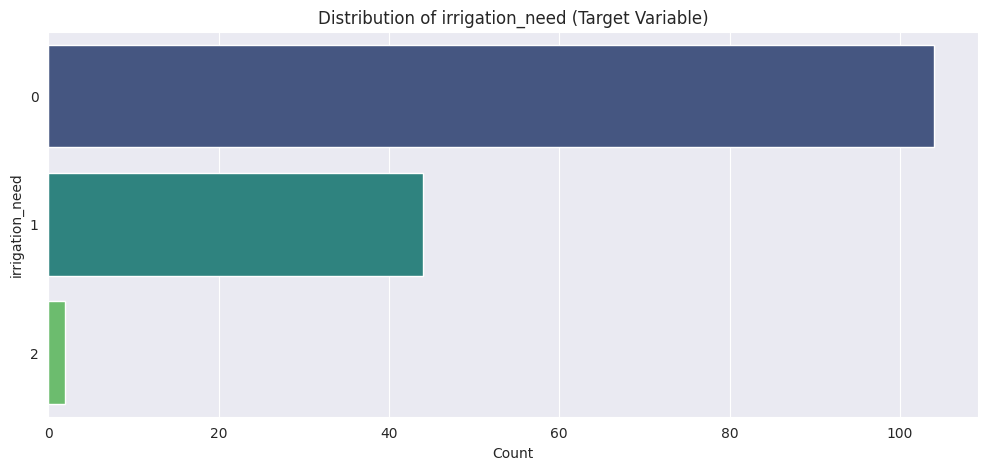

In [23]:
# Plot target
eda.target_plot()

---
### 📊 Visualize Data Distribution (Univariate Analysis)

#### Numeric Features



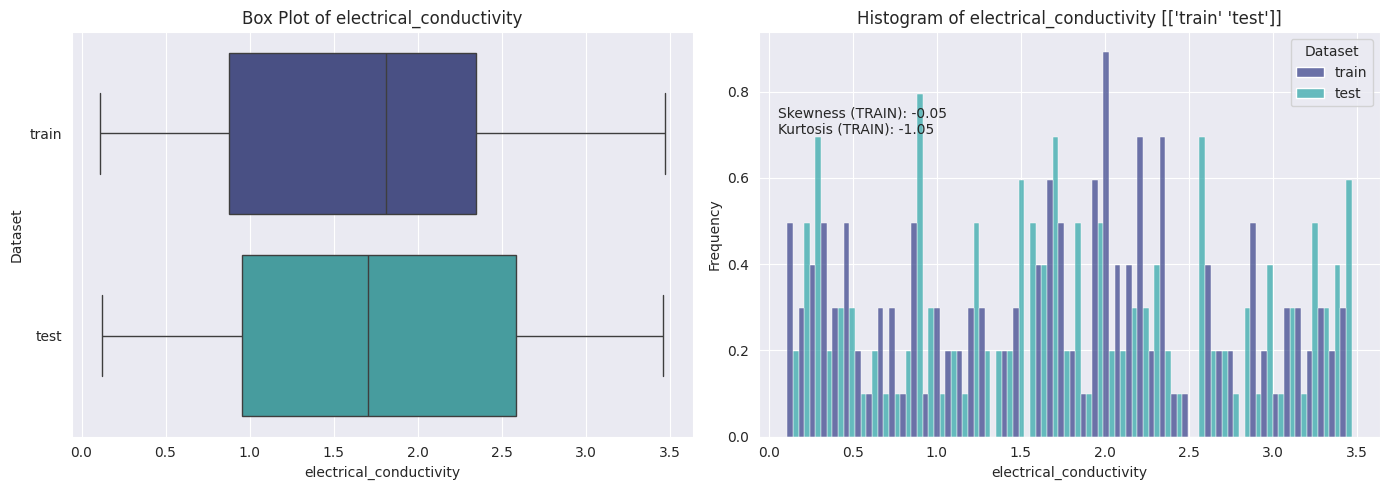

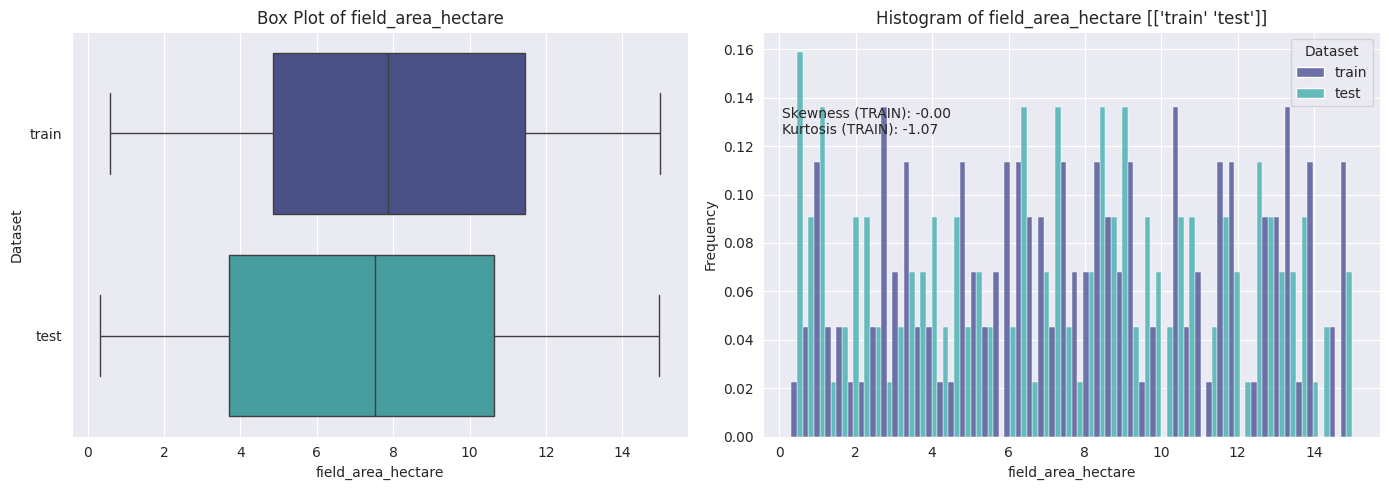

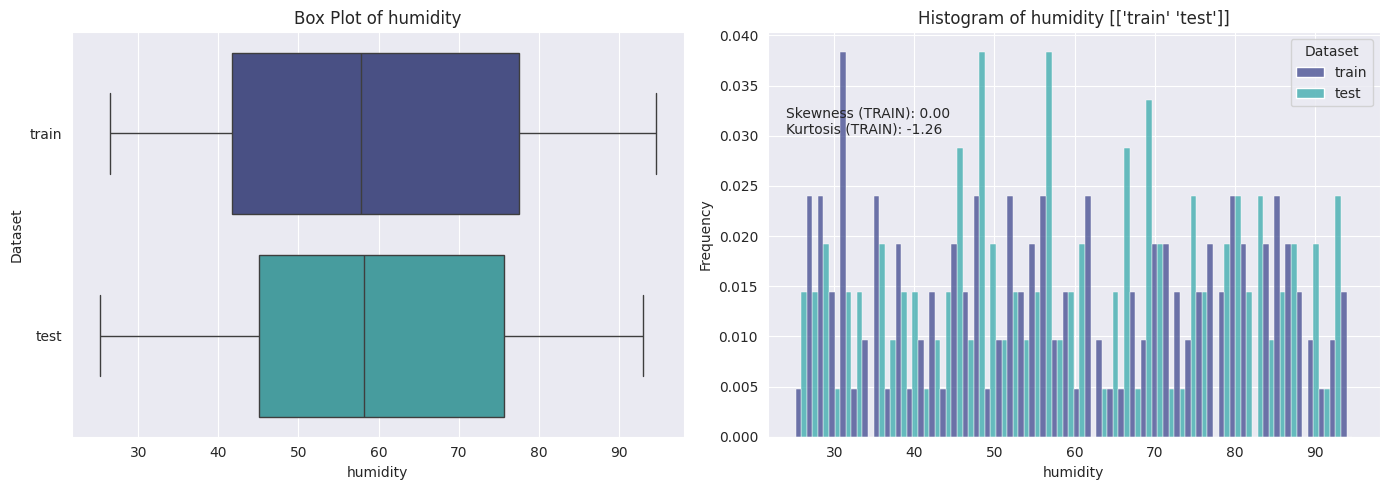

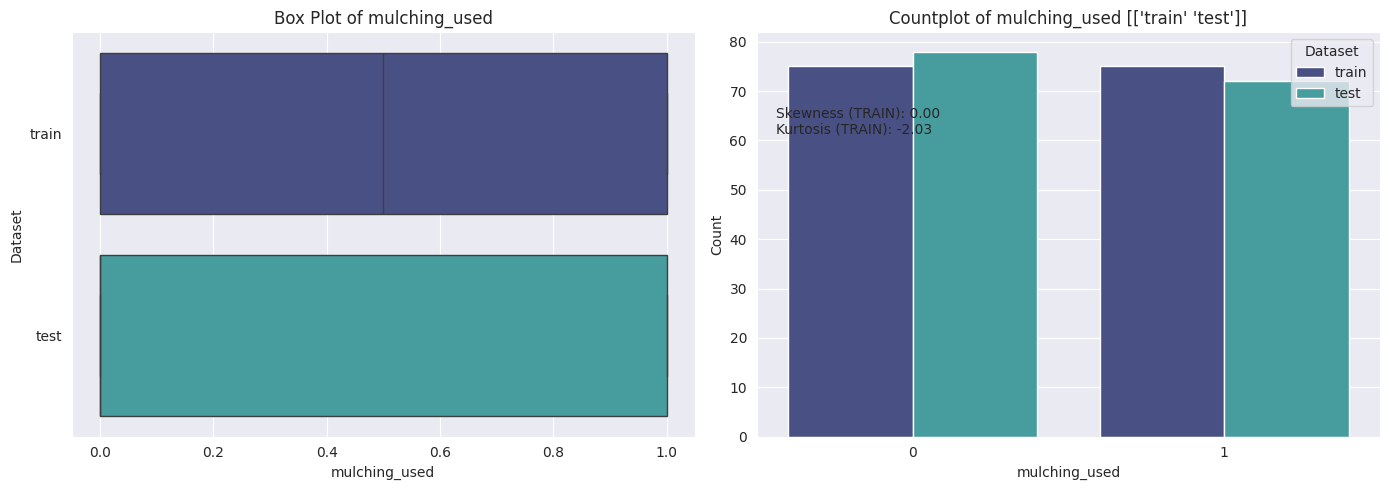

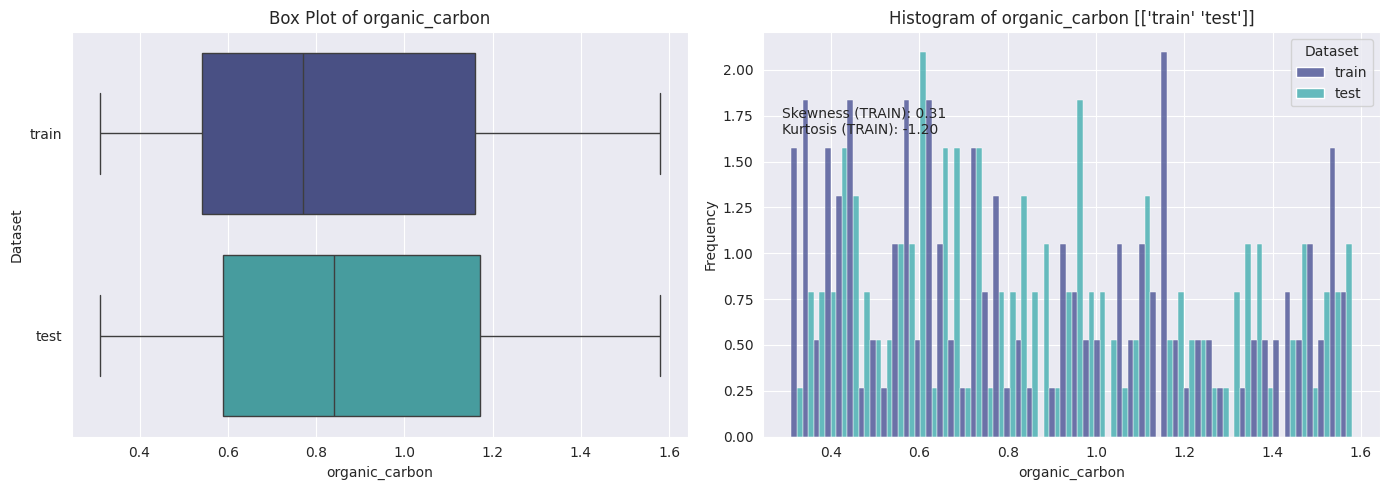

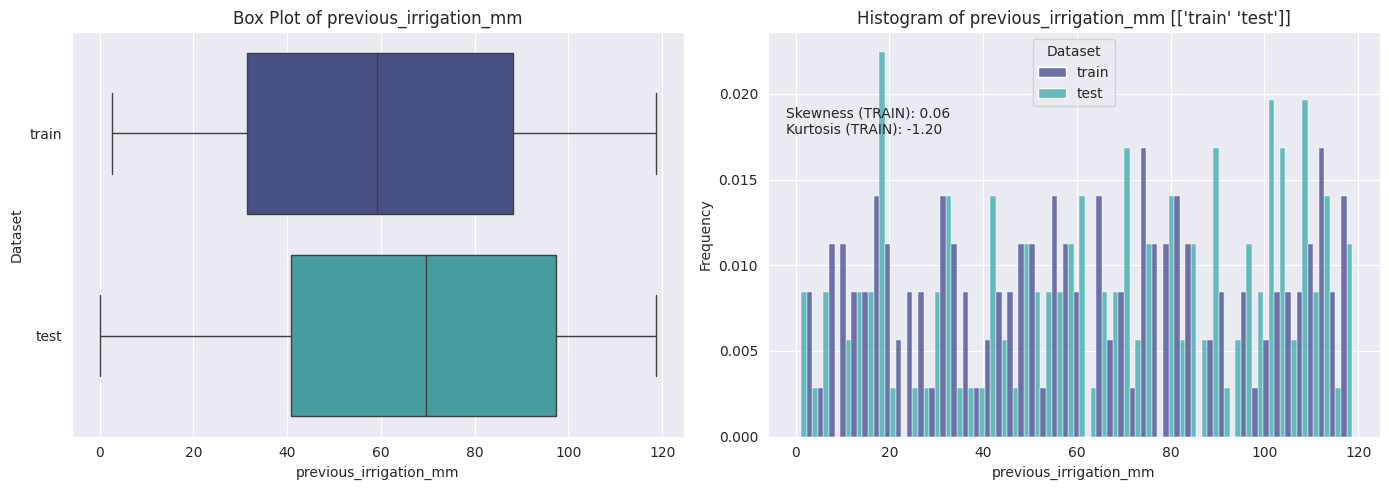

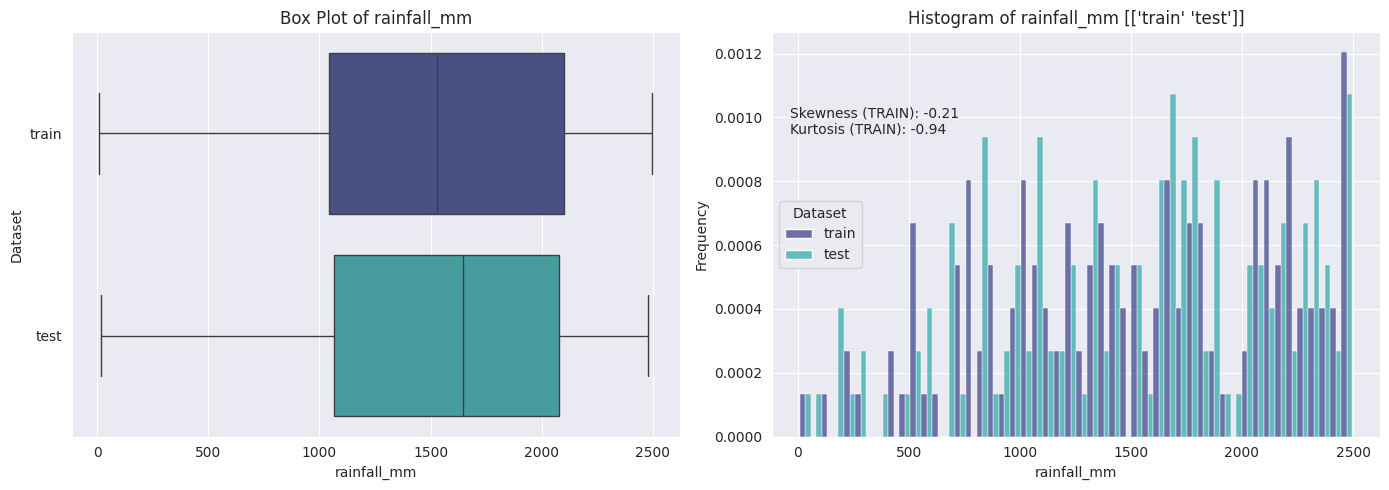

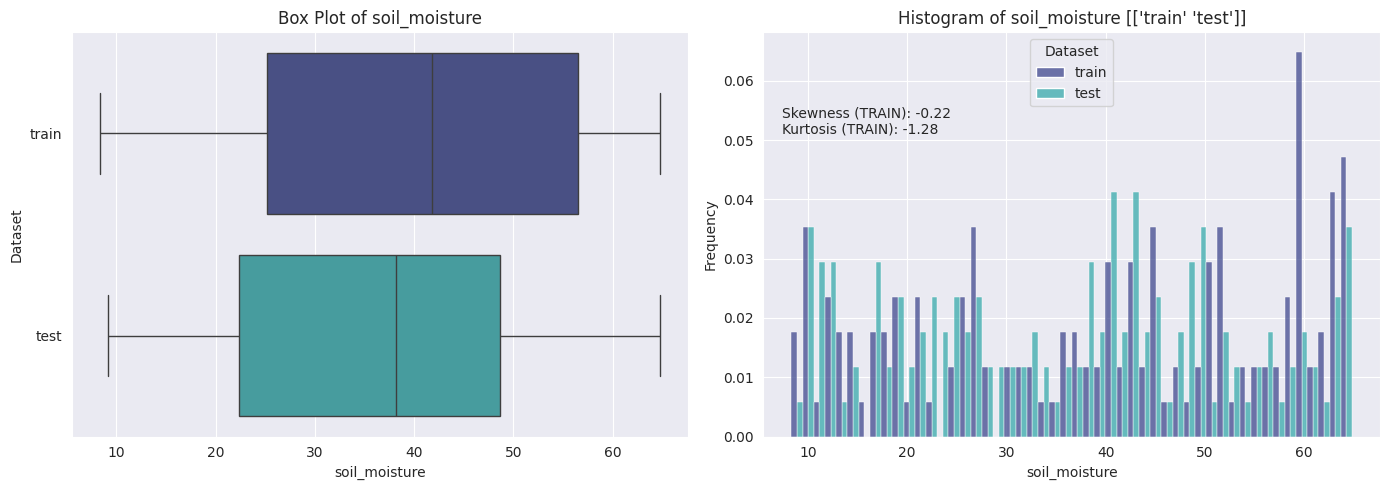

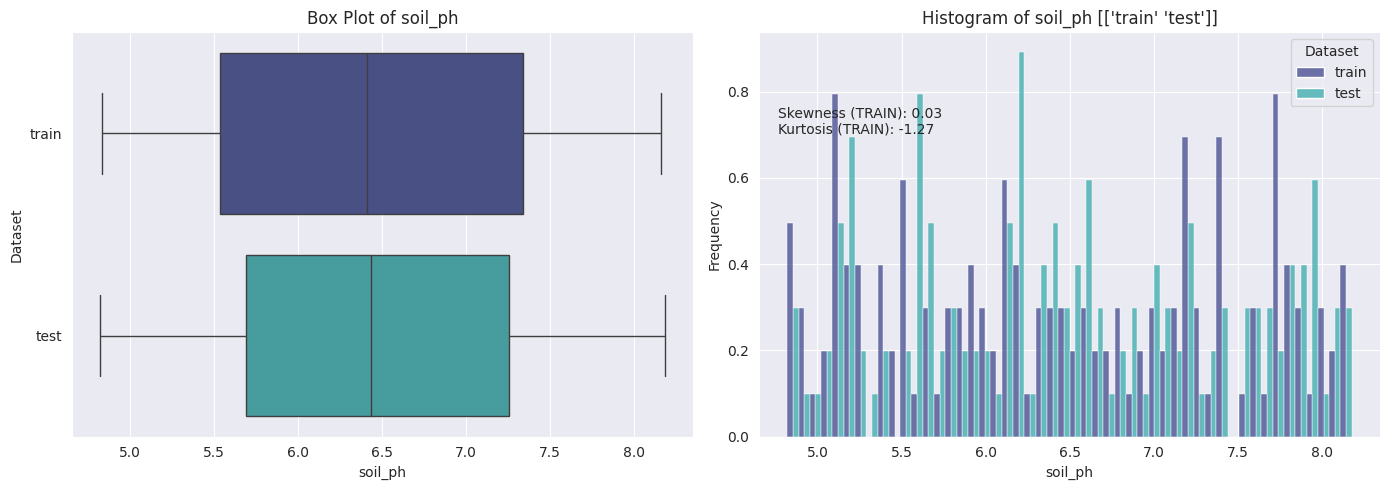

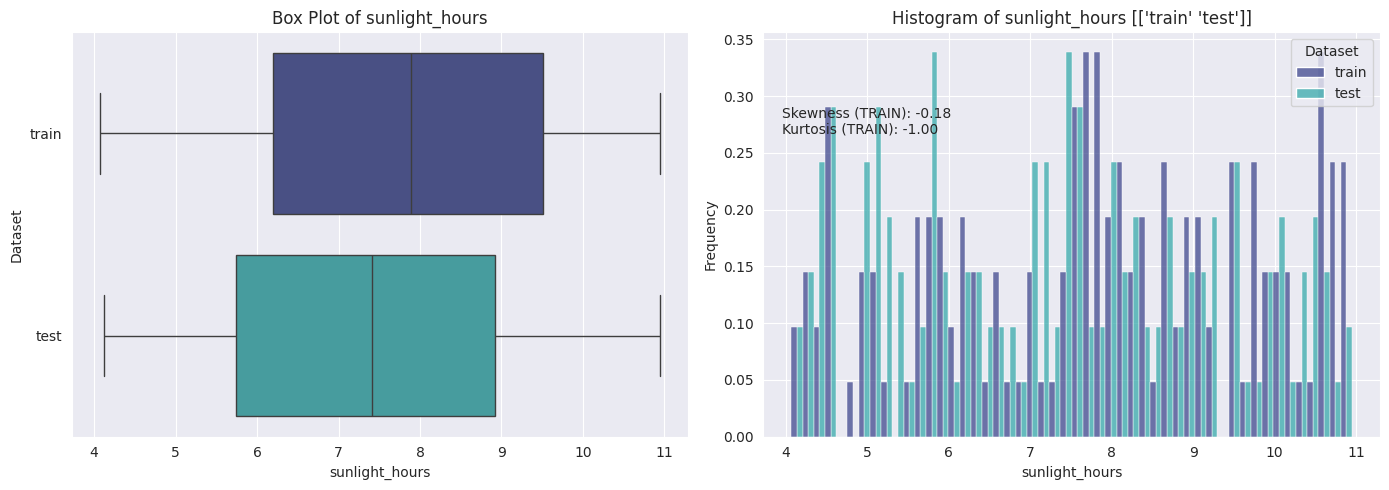

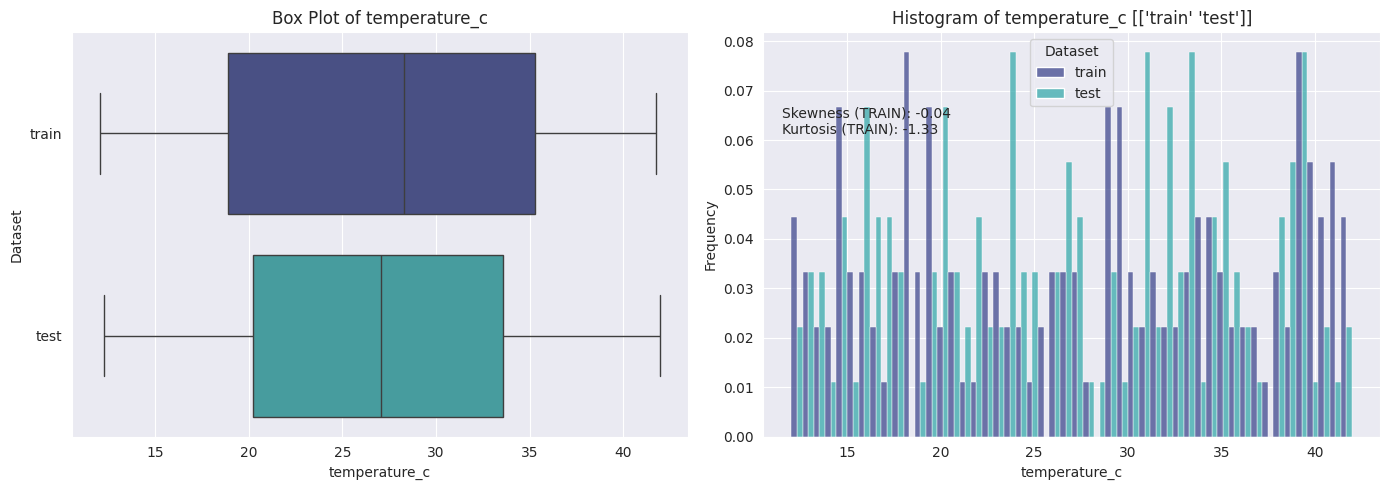

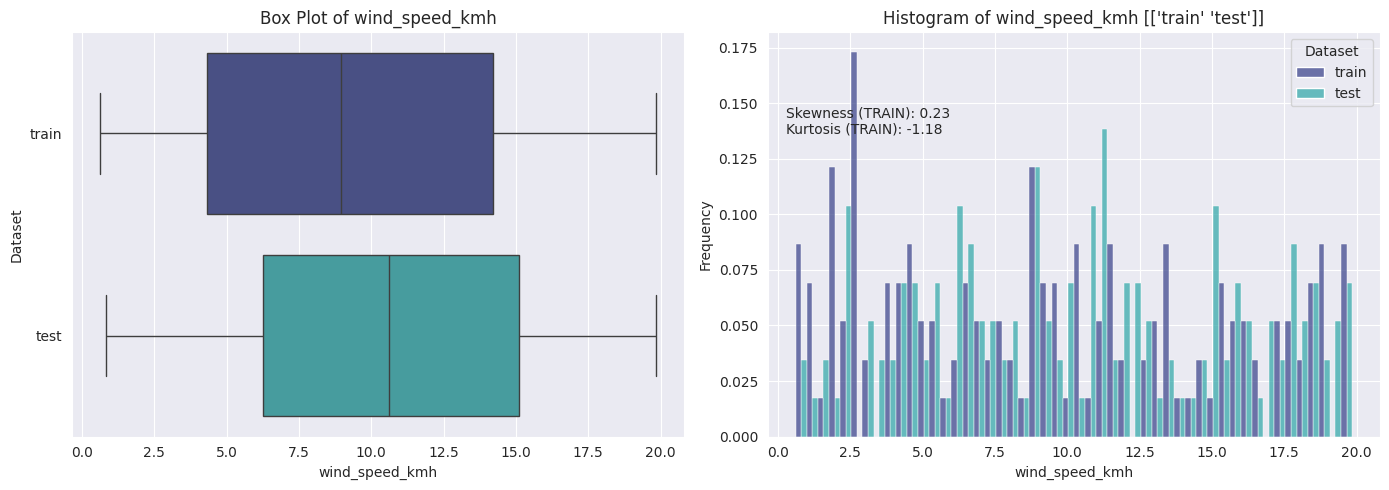

In [24]:
# Perform univariate analysis for each numerical variable
eda.numeric_univariate_plots()

#### Categorical features

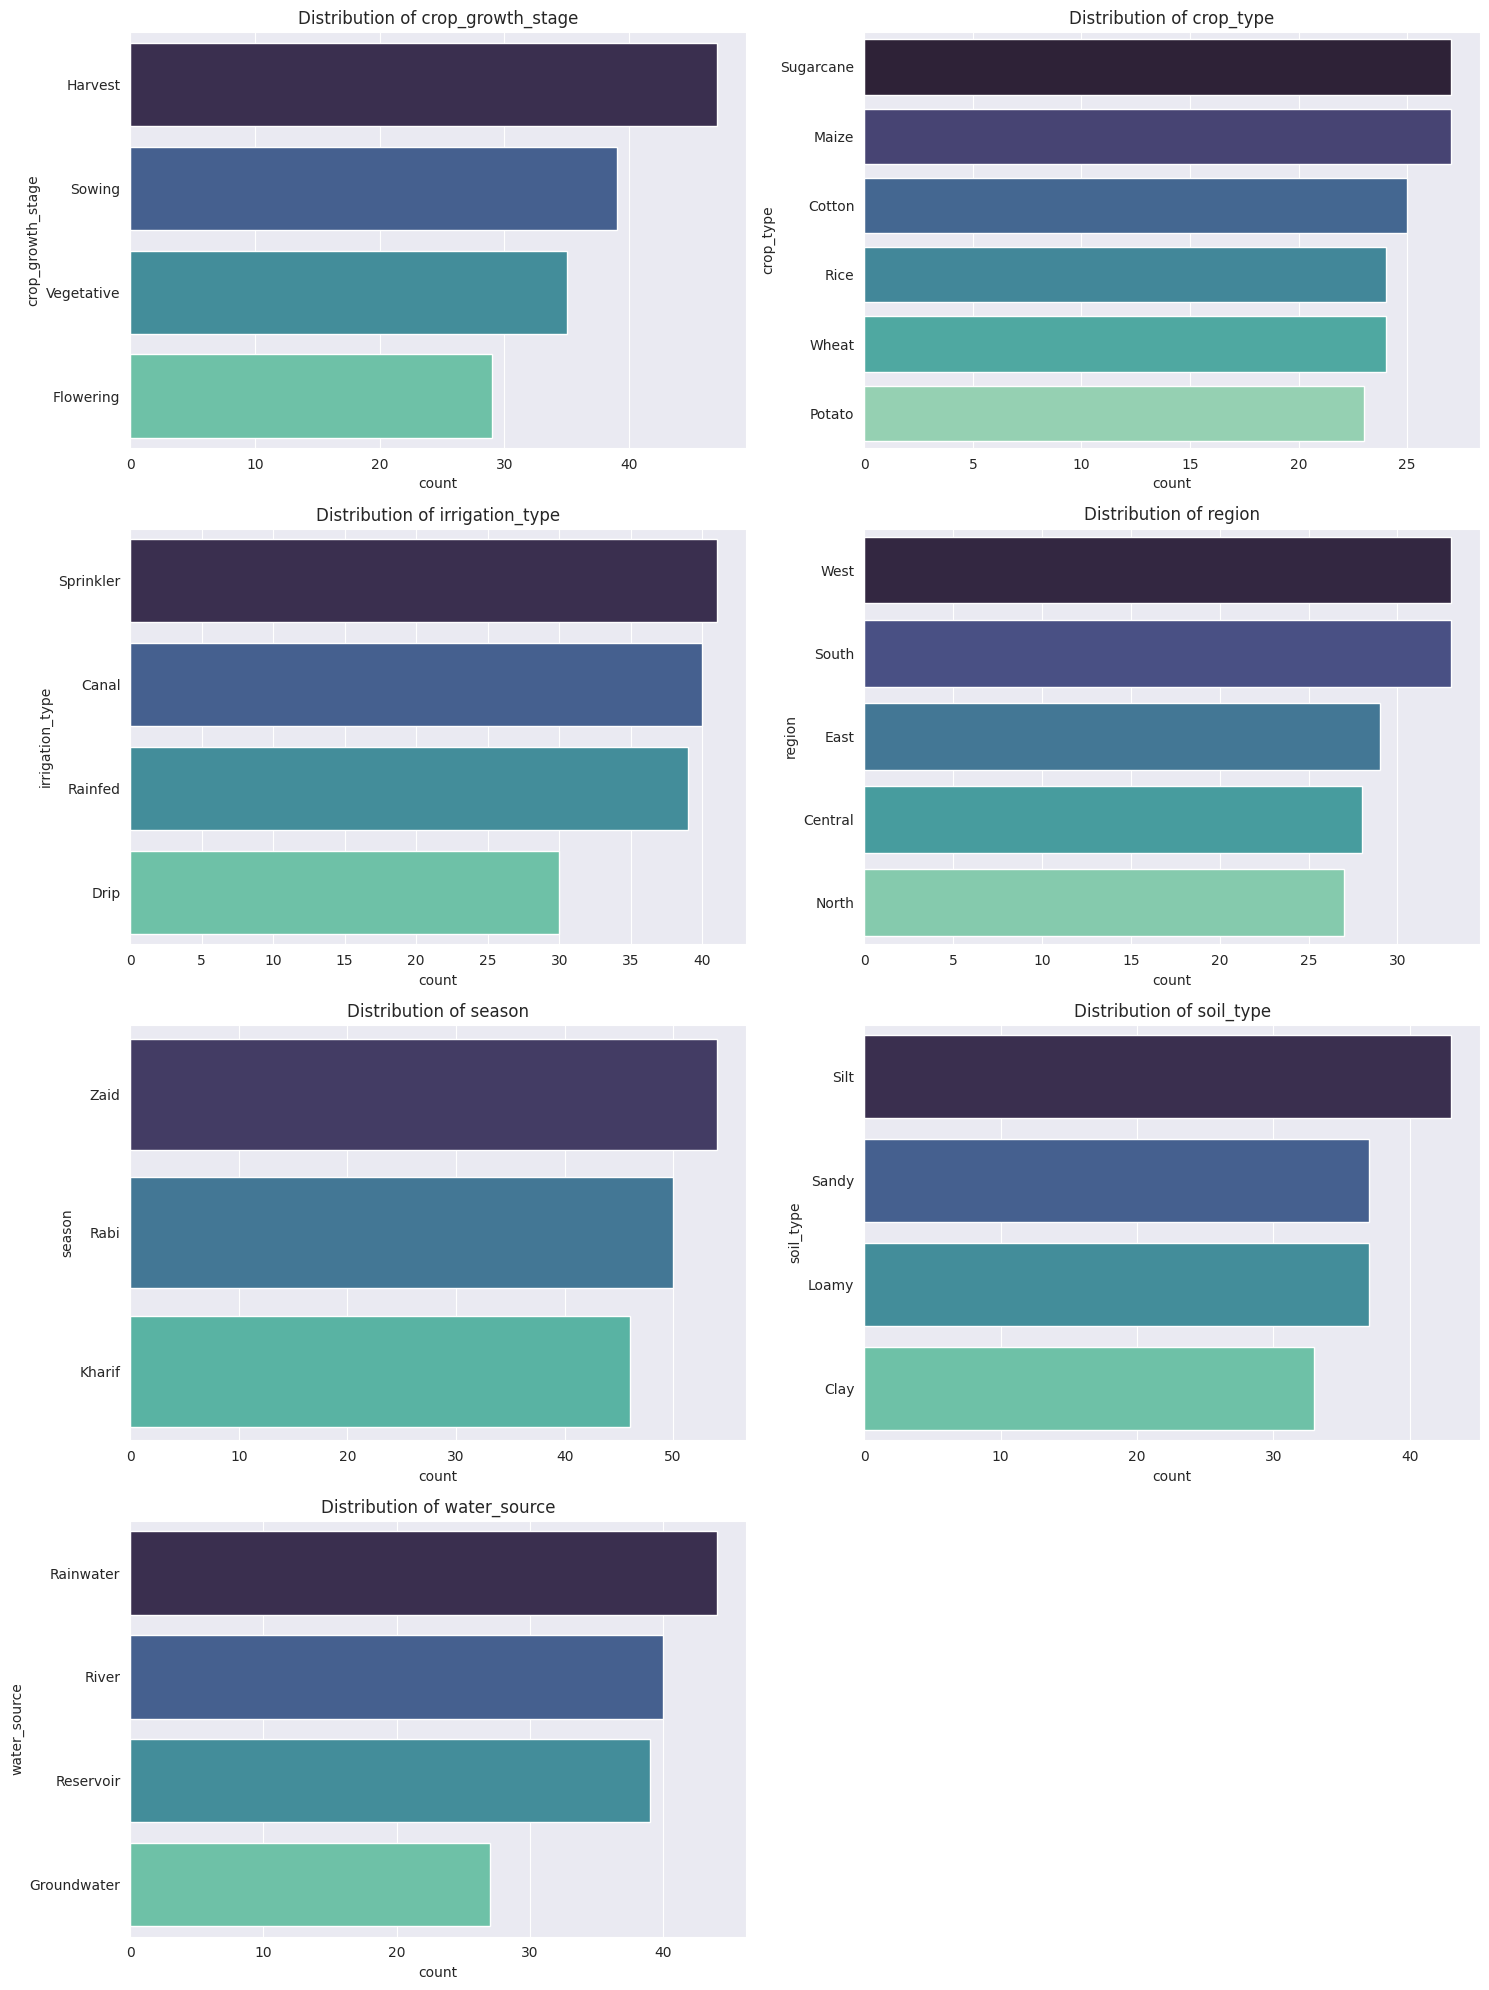

In [25]:
eda.categorical_plot()

### 📊 Correlations - Bivariate Analysis

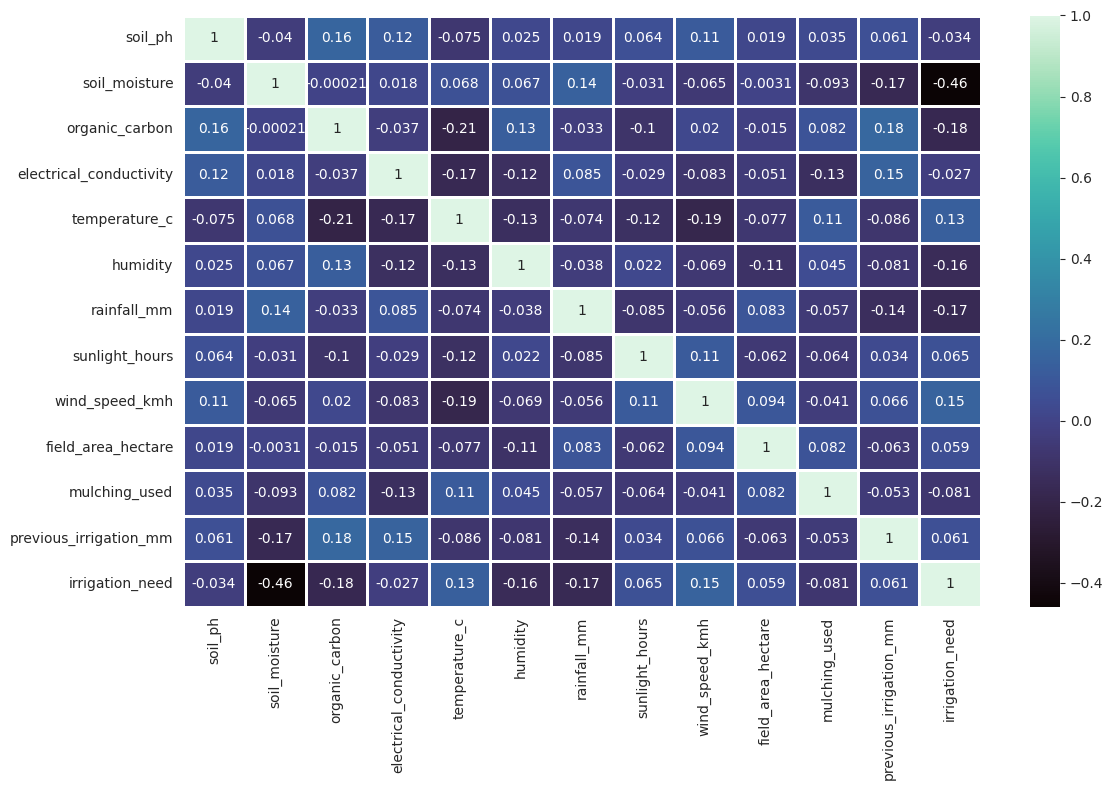

In [26]:
# Create a heatmap to visualize the correlation matrix of the TRAIN_DF DataFrame
eda.correlation_plot()

## ⚔️ Adversarial validation

In [27]:
if config.data.add_extra_data:
    print("ℹ️ Adversarial validation step.")
    AV_RESULTS = adversarial_validation(
        datasets=datasets,
        print_details=False,
    )
    if AV_RESULTS > config.model.adversarial_threshold:
        print(f"Adversarial threshold exceeded: {config.model.adversarial_threshold} < {AV_RESULTS:.2f}")
    else:
        print(f"Adversarial threshold NOT exceeded: {config.model.adversarial_threshold} > {AV_RESULTS:.2f}")
        print("ℹ️ Concatenating...")
        datasets["train"] = pd.concat([
            datasets["train"],
            datasets["extra"],
        ], axis=0, ignore_index=True)
else:
    print("ℹ️ No adversarial validation step.")

ℹ️ No adversarial validation step.


---
## 🛠 Feature Engineer

In [28]:
# Define X and y
X = datasets["train"].copy()
X_test = datasets["test"].copy()
y = X.pop(config.data.target)

if config.model.task_type == 'classification':
    if len(y.unique()) == 2:
        scale_pos_weight = (y == 0).sum() / (y == 1).sum()
    else:
        scale_pos_weight = 1 # default

In [29]:
# Preprocess data

# drop target from NUMERIC_FEATURES
if config.data.target in NUMERIC_FEATURES:
    NUMERIC_FEATURES.remove(config.data.target)

if config.data.add_features:
    print("ℹ️ Feature engineering step.")
    X       = preprocessing(X, numeric_features=NUMERIC_FEATURES)
    X_test  = preprocessing(X_test, numeric_features=NUMERIC_FEATURES)
else:
    print("ℹ️ No feature engineering step.")

ℹ️ No feature engineering step.


In [30]:
if config.data.feature_selection:
    print("ℹ️ Feature selection step.")

    # Prepare Categorical Indices for CatBoost/LGBM
    CAT_COLS = X.select_dtypes(["category", "object"]).columns.tolist()
    cat_features_indices = [X.columns.get_loc(col) for col in CAT_COLS]

    # Convert categorical columns to 'category' dtype for XGBoost compatibility
    for col in CAT_COLS:
        X[col] = X[col].astype('category')

    # "Light" versions of models for speed
    # Lower complexity here just to identify feature signal
    importance_models = {
        "XGB": XGBClassifier(n_estimators=500, max_depth=4, device=config.env.device, random_state=config.env.seed, enable_categorical=True),
        "LGBM": LGBMClassifier(n_estimators=500, num_leaves=30, device=config.env.device, random_state=config.env.seed),
        "CAT": CatBoostClassifier(iterations=500, depth=6, verbose=0, task_type=config.env.device.upper(), random_state=config.env.seed)
    }

    importance_results = pd.DataFrame(index=X.columns)

    print("=== Running Consensus Importance Pass ===")
    for name, model in importance_models.items():
        print(f"Fitting {name}...")

        if name == "CAT":
            model.fit(X, y, cat_features=CAT_COLS)
            importance_results[name] = model.get_feature_importance()
        elif name == "LGBM":
            model.fit(X, y, categorical_feature=CAT_COLS)
            importance_results[name] = model.feature_importances_
        else: # XGB
            model.fit(X, y)
            importance_results[name] = model.feature_importances_

        # Normalize scores to 0-100 to make them comparable
        importance_results[name] = (importance_results[name] / importance_results[name].sum()) * 100

    # Calculate Global Score and Perform Selection
    importance_results['mean_importance'] = importance_results.mean(axis=1)
    importance_results = importance_results.sort_values('mean_importance', ascending=False)

    # Plot average feature importance
    plt.figure(figsize=(15,8))
    sns.barplot(
        data=importance_results,
        y=importance_results.index,
        x='mean_importance'
    )

else:
    print("ℹ️ No feature selection step.")

ℹ️ No feature selection step.


In [31]:
if config.data.feature_selection:
    # Selection: Keep features that contribute at least 2% or are in top 30
    THRESHOLD = 2
    SELECTED_FEATURES = importance_results[importance_results['mean_importance'] > THRESHOLD].index.tolist()
    print(f"\nSelection Complete: {len(SELECTED_FEATURES)} features retained.")
    print(f"Dropped: {len(X.columns) - len(SELECTED_FEATURES)} features.")

    X = X[SELECTED_FEATURES]
    X_test = X_test[SELECTED_FEATURES]

---
## Hyperparameter Optimization

In [32]:
if config.model.hp_search:
    print("ℹ️ Hyperparameter Optimization step")
    # Optimize with Optuna
    study_results = dict()
    for model_type in ["xgboost", "lightgbm", "catboost"]:
      study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=config.env.seed))
      study.optimize(
          lambda trial: objective(
              trial,
              X.sample(frac=.05, random_state=config.env.seed),
              y.sample(frac=.05, random_state=config.env.seed),
              model_type=model_type
          ),
          n_trials=config.model.optuna_trials, timeout=7200)

      # Nest params, value and trial within each model's dictionary
      model_results = dict()
      model_results["Model"] = model_type
      model_results["Best params:"] = study.best_params
      model_results["Best value:"] = study.best_value
      model_results["Best trial:"] = study.best_trial

      # Append to study results
      study_results[model_type] = model_results

    # Display the results
    study_df = pd.DataFrame.from_records(study_results)
    for model_type in ["xgboost", "lightgbm", "catboost"]:
      display(pd.DataFrame.from_records(study_results[model_type]))

else:
    print("ℹ️ No hyperparameter optimization step.")

ℹ️ No hyperparameter optimization step.


In [33]:
common = {
    'random_state': config.env.seed,
    'n_estimators': 3000,
    }

if config.model.task_type == 'classification' and len(y.unique()) == 2:
    common['scale_pos_weight'] = scale_pos_weight

if config.model.optimized_params:

  print("ℹ️ Using optimized hyperparameters.")
  HYPERPARAMS = {
      'xgboost' : {
          **common,
          'objective': 'binary:logistic',
          "device": config.env.device,
          "early_stopping_rounds":100,
          'enable_categorical': True,
          'n_estimators': 1009,
          'learning_rate': 0.011943333544787549,
          'max_depth': 8,
          'subsample': 0.9143965635679931,
          'colsample_bytree': 0.7670542318585548,
          'reg_alpha': 3.0303575179672426e-05,
          'reg_lambda': 1.0218338193771584e-06,
      },

      'lightgbm' : {
          **common,
          'objective': 'binary',
          "device": config.env.device,
          'learning_rate': 0.030159004697110012,
          'num_leaves': 81,
          'min_child_samples': 56,
          'subsample': 0.7668992634198386,
          'colsample_bytree': 0.7539783365264743,
          'reg_alpha': 2.5249266600932376,
          'reg_lambda': 1.2022289464728586,
      },

      'catboost'  : {
          **common,
          "task_type": config.env.device.upper(),
          'iterations': 909,
          'learning_rate': 0.1056470526055604,
          'depth': 6,
          'l2_leaf_reg': 9.897294454000193,
      }
  }

else:
    print("ℹ️ Using default hyperparameters.")
    DEFAULT_HYPERPARAMS = dynamic_default_params(X, y, device=config.env.device, seed=config.env.seed)

ℹ️ Using default hyperparameters.


---
## Training

In [ ]:
n_classes = len(y.unique())

# Define estimators group with best hyperparams (if available)
estimators = [
    ('xgboost',  XGBClassifier(**HYPERPARAMS['xgboost']) if config.model.optimized_params else XGBClassifier(**DEFAULT_HYPERPARAMS['xgboost'])),
    ('lightgbm', LGBMClassifier(**HYPERPARAMS['lightgbm']) if config.model.optimized_params else LGBMClassifier(**DEFAULT_HYPERPARAMS['lightgbm'])),
    ('catboost', CatBoostClassifier(**HYPERPARAMS['catboost']) if config.model.optimized_params else CatBoostClassifier(**DEFAULT_HYPERPARAMS['catboost']))
]

# Initialize dictionaries to keep predictions from each model
OOF_PROBS   = {model_type: np.zeros((len(X), n_classes)) for model_type, _ in estimators}
TEST_PROBS  = {model_type: np.zeros((len(X_test), n_classes)) for model_type, _ in estimators}
FOLD_SCORES = dict()

# Initialize skf (outside of loop so each model gets the same splits)
skf = StratifiedKFold(n_splits=config.data.folds, shuffle=True, random_state=config.env.seed)

# Start model loop
print("ℹ️ Model training step.")
for model_type, model in estimators:

    # Define empty oof variables to fill
    oof_preds_proba_model = np.zeros(shape = (len(X), n_classes))
    test_preds_proba_model = np.zeros(shape = (len(X_test), n_classes))
    fold_scores = []

    # Category conversion
    TE_COLS = []
    X_temp = X.copy()
    X_test_temp = X_test.copy()

    # Convert categorical columns for the current copies used in the loop
    for col in CATEGORICAL_FEATURES + TE_COLS:
        if col in X_temp.columns:
            X_temp[col] = X_temp[col].astype("category")
        if col in X_test_temp.columns:
            X_test_temp[col] = X_test_temp[col].astype("category")

    print(f"\n{'='*20} Fitting {model_type} {'='*20}")
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_temp, y)):
        print(f"\n{'#'*10} Fold {fold+1}/{config.data.folds} {'#'*10}")

        # Define splits. iqr_outlier_capping internally copies the dataframes.
        x_train, x_valid, _ = iqr_outlier_capping(
            X_temp.iloc[train_idx], X_temp.iloc[valid_idx], None,
            columns = X_temp.select_dtypes(np.number).columns.difference([config.data.target])
        )
        y_train, y_valid    = y.iloc[train_idx], y.iloc[valid_idx]
        x_test_loop         = X_test_temp.copy()

        current_categorical_features = CATEGORICAL_FEATURES
        if config.data.use_te:
            print("ℹ️ Target Encoding step.")
            target_enc = TargetEncoder(target_type='auto', smooth='auto', cv=4, shuffle=True, random_state=config.env.seed)
            x_train[TE_COLS]     = target_enc.fit_transform(x_train[TE_COLS], y_train)
            x_valid[TE_COLS]     = target_enc.transform(x_valid[TE_COLS])
            x_test_loop[TE_COLS] = target_enc.transform(x_test_loop[TE_COLS])

            # Remove TE_COLS from the categorical list for this fold, as they are now numeric
            current_categorical_features = [c for c in CATEGORICAL_FEATURES if c not in TE_COLS]

        start = time.time()

        if model_type == "xgboost":
            model.fit(x_train, y_train,
                    eval_set=[(x_valid, y_valid)],
                    verbose=200
                    )
        elif model_type == "lightgbm":
            model.fit(x_train, y_train,
                      eval_set=(x_valid, y_valid),
                      categorical_feature=current_categorical_features,
                      callbacks = [
                          lgb.early_stopping(stopping_rounds=100, verbose=200)],
                     )
        elif model_type == "catboost":
            model.fit(x_train, y_train,
                      eval_set=(x_valid, y_valid),
                      cat_features=current_categorical_features,
                      verbose=200,
                      early_stopping_rounds=100
                     )

        # Get probabilities for OOF and test
        oof_preds_proba_model[valid_idx] = model.predict_proba(x_valid)
        test_preds_proba_model += model.predict_proba(x_test_loop)

        # Calculate fold score using predicted classes from probabilities
        preds_labels = np.argmax(model.predict_proba(x_valid), axis=1)
        fold_score = balanced_accuracy_score(y_valid, preds_labels)
        fold_scores.append(fold_score)
        print(f" Fold {fold+1}: Balanced Accuracy Score: {fold_score:.5f}")

        end = time.time()
        print(f"Fold {fold+1} finished in {end - start:.2f} seconds")

    mean_valid_score = np.mean(fold_scores)
    print(f"Balanced Accuracy Score: {mean_valid_score:.3f}")

    # Average test probabilities across folds
    test_preds_proba_model /= config.data.folds

    # Save OOF and test probabilities + fold scores by model
    OOF_PROBS[model_type]   = oof_preds_proba_model
    TEST_PROBS[model_type]  = test_preds_proba_model
    FOLD_SCORES[model_type] = fold_scores

In [ ]:
scores_df = pd.DataFrame(FOLD_SCORES)

# Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=scores_df, palette="mako", orient='h')

# Add titles and labels
plt.title('Score Distribution Across Targets', fontsize=16, weight='bold')
plt.xlabel('RMSE', fontsize=14)
plt.ylabel('Models', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
if config.model.search_weights:
    if config.model.search_weights:
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=config.env.seed))
        study.optimize(weights_optimization, n_trials = config.model.optuna_trials*10, timeout=3600)

In [ ]:
# Print best params (weights)
print(study.best_params)

---
## ✅ Submission

In [ ]:
# Define best weights and threshold
# Check if weights optimization was performed, otherwise use equal weights
if config.model.search_weights:
    if 'study' in locals() and study.best_params:
        w1 = study.best_params.get("w1", 1/3)
        w2 = study.best_params.get("w2", 1/3)
        w3 = 1 - (w1 + w2)
        print(f"Using optimized weights: w1={w1:.3f}, w2={w2:.3f}, w3={w3:.3f}")
    else:
        # Fallback if optimization didn't run or failed
        w1, w2, w3 = 1/3, 1/3, 1/3
        print(
            "Weights optimization skipped or failed. "
            "Using equal weights: w1={w1:.3f}, w2={w2:.3f}, w3={w3:.3f}"
            )
else:
    # Use equal weights if optimization is not enabled
    w1, w2, w3 = 1/3, 1/3, 1/3
    print(
        "Weights optimization not enabled. "
        f"Using equal weights: w1={w1:.3f}, w2={w2:.3f}, w3={w3:.3f}"
        )


# Weighted ensemble of model probabilities
# TEST_PROBS contains probabilities for each class from each model
ensemble_probabilities = (
    w1 * TEST_PROBS["xgboost"]  +
    w2 * TEST_PROBS["lightgbm"] +
    w3 * TEST_PROBS["catboost"]
)

# Convert ensemble probabilities to class labels
ensemble_predictions_labels = np.argmax(ensemble_probabilities, axis=1)

# Reverse map numerical labels back to original string labels
reverse_irrigation_map = {v: k for k, v in CUSTOM_MAPS['irrigation_need'].items()}
final_predictions_string = pd.Series(ensemble_predictions_labels).map(reverse_irrigation_map)

# Submission ids
submission_ids = pd.read_csv(f'{config.data.data_path}/sample_submission.csv').id.to_list()

# Prepare submission df
if not config.env.smoke_test:
    submission_df = pd.DataFrame({
        "id": submission_ids,
        config.data.target : final_predictions_string
    })
else:
    submission_df = pd.DataFrame({
        "id": submission_ids[:len(final_predictions_string)],
        config.data.target : final_predictions_string
    })
# Display the first rows (sanity check)
display(submission_df.head())

# Save to CSV
submission_df.to_csv('submission.csv', index=False)